In [22]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
r=2.0 #logistic映射参数
N=500 #格子大小

In [24]:
# 1. 离散化区间 [-1, 1]
edges = np.linspace(-1, 1, N + 1)
centers = (edges[:-1] + edges[1:]) / 2

In [25]:
# 2. 构造转移矩阵 P (Perron-Frobenius 算子的离散近似)
P = np.zeros((N, N))

In [26]:
# 对每个格子中心点进行映射，看它落到哪个新格子
for j in range(N):
    x_next = 1 - r * (centers[j]**2) #映射值
    # 找到落在哪个 bin (利用 searchsorted 快速定位)
    i = np.searchsorted(edges, x_next) - 1 #顺序数第几个格子
    P[i, j] = 1.0  # 确定性映射
    #print(i,j,1)

In [27]:
# 3. 计算特征值
eigenvalues = np.linalg.eigvals(P)
#eigenvalues

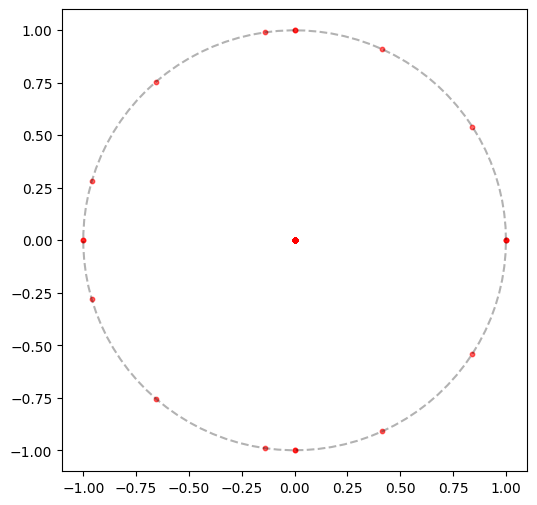

In [28]:
# 4. 绘图
plt.figure(figsize=(6, 6))
# 画出单位圆
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)

# 画出特征值分布
plt.scatter(eigenvalues.real, eigenvalues.imag, s=10, c='red', alpha=0.6)